Diabetes Prediction using Machine Learning - Binary Classification

In [1]:
#importing necessary dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data
data=pd.read_csv("/content/diabetes.csv")

In [3]:
data.head() #first 5 records by default

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Part 1 - Data Preparation

In [4]:
data.shape #(rows, columns) -> 768 rows and 9 columns

(768, 9)

In [5]:
data.columns #column names present in the dataset

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
data.info() #datatypes and non-null counts of every column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.dtypes #all columns are numeric (int/float), Outcome is the target variable (0/1)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
data.isnull().sum() #no explicit NaN values in the dataset

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
data.describe() #basic statistical summary

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Note: some columns cannot biologically be 0 (Glucose, BloodPressure, SkinThickness, Insulin, BMI). A value of 0 in these columns is really a missing value that was encoded as 0, not a true measurement.

In [10]:
#checking how many 0s (hidden missing values) are present in these columns
cols_with_invalid_zero=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols_with_invalid_zero].isin([0]).sum()
#Insulin (374) and SkinThickness (227) have the most hidden missing values

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [11]:
#replacing the invalid 0s with NaN so they can be treated as missing values
data[cols_with_invalid_zero]=data[cols_with_invalid_zero].replace(0,np.nan)
data.isnull().sum() #now the missing values are visible

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
#replacing missing values using SimpleImputer (median strategy, since these columns are skewed)
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy='median')
data[cols_with_invalid_zero]=num_imputer.fit_transform(data[cols_with_invalid_zero])
data.isnull().sum() #missing values from the dataset are now handled

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

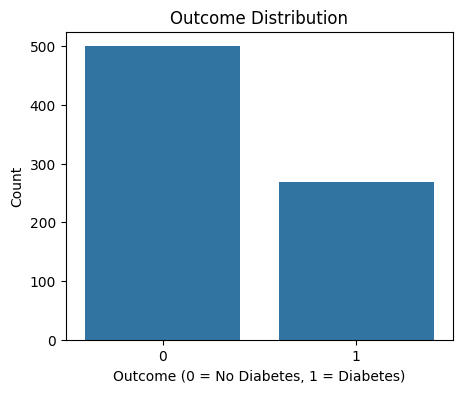

In [13]:
#target variable distribution
outcome_counts=data['Outcome'].value_counts()
plt.figure(figsize=(5,4))
sns.barplot(x=outcome_counts.index,y=outcome_counts.values)
plt.title('Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()
#500 patients do not have diabetes and 268 patients have diabetes - the classes are moderately imbalanced

In [14]:
#Dividing the data into 'X' [input independent columns] and 'y' [output dependent column]
X=data.drop(['Outcome'],axis=1) #input independent columns, excluding the target column
y=data['Outcome'] #output dependent (target) column

In [15]:
#Splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
#20% of the data is used for evaluating the performance and rest 80% data is used for training the model
#stratify=y keeps the same proportion of diabetic/non-diabetic patients in both sets
print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (614, 8)
Testing set size: (154, 8)


In [16]:
#Scaling the numeric features - important for distance/gradient based models like Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
#Note: Decision Tree and Random Forest do not require scaling (they split on raw feature values),
#but Logistic Regression benefits from scaled features

Part 2 - Machine Learning Model Building

Three classification algorithms are implemented and compared:

- **Logistic Regression** - a simple, interpretable linear model that estimates the probability of diabetes; a good baseline for binary classification.
- **Decision Tree Classifier** - splits the data on feature thresholds (e.g. Glucose > 127.5); easy to interpret but prone to overfitting.
- **Random Forest Classifier** - an ensemble of many decision trees; usually more accurate and more robust to overfitting than a single tree.

Key parameters used: `max_iter=1000` for Logistic Regression (allows the optimizer to converge), `max_depth=5` for the Decision Tree and `max_depth=6, n_estimators=100` for the Random Forest (limits tree depth to control overfitting).

How each model predicts: Logistic Regression outputs a probability using a sigmoid function and classifies as 1 if probability > 0.5. The Decision Tree follows a series of if-else feature splits down to a leaf node. The Random Forest averages the predictions (majority vote) of all 100 trees.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg=LogisticRegression(max_iter=1000,random_state=42)
dec_tree=DecisionTreeClassifier(max_depth=5,random_state=42)
rand_forest=RandomForestClassifier(n_estimators=100,max_depth=6,random_state=42)

Part 3 - Model Training

In [18]:
#training all 3 models - Logistic Regression uses the scaled features, tree-based models use raw features
log_reg.fit(X_train_scaled,y_train)
dec_tree.fit(X_train,y_train)
rand_forest.fit(X_train,y_train)
print('All models trained')

All models trained


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#generating predictions on the TRAINING set to check training performance
log_reg_train_pred=log_reg.predict(X_train_scaled)
dec_tree_train_pred=dec_tree.predict(X_train)
rand_forest_train_pred=rand_forest.predict(X_train)

print('Logistic Regression training accuracy:',accuracy_score(y_train,log_reg_train_pred))
print('Decision Tree training accuracy:',accuracy_score(y_train,dec_tree_train_pred))
print('Random Forest training accuracy:',accuracy_score(y_train,rand_forest_train_pred))

Logistic Regression training accuracy: 0.7964169381107492
Decision Tree training accuracy: 0.8143322475570033
Random Forest training accuracy: 0.8843648208469055


In [20]:
#generating predictions on the TEST set as well, so we can compare train vs test performance
log_reg_test_pred=log_reg.predict(X_test_scaled)
dec_tree_test_pred=dec_tree.predict(X_test)
rand_forest_test_pred=rand_forest.predict(X_test)

print('Logistic Regression test accuracy:',accuracy_score(y_test,log_reg_test_pred))
print('Decision Tree test accuracy:',accuracy_score(y_test,dec_tree_test_pred))
print('Random Forest test accuracy:',accuracy_score(y_test,rand_forest_test_pred))
#Random Forest has the highest training accuracy but that alone does not mean it is the best model - need to check test performance too (below)

Logistic Regression test accuracy: 0.7077922077922078
Decision Tree test accuracy: 0.7597402597402597
Random Forest test accuracy: 0.7402597402597403


**Observation on overfitting/underfitting:** Random Forest has the highest training accuracy (~88%) but its test accuracy (~74%) is noticeably lower - a sign of mild overfitting (the model partly memorized the training data). The Decision Tree's train (~81%) and test (~76%) accuracies are closer together. Logistic Regression underfits slightly since it is a simple linear model, but its train/test gap is small too, meaning it generalizes consistently even if its raw accuracy is a bit lower.

Part 4 - Model Evaluation

In [21]:
#Evaluating Logistic Regression on the test set
print('--- Logistic Regression ---')
print('Accuracy:',accuracy_score(y_test,log_reg_test_pred))
print('Precision:',precision_score(y_test,log_reg_test_pred))
print('Recall:',recall_score(y_test,log_reg_test_pred))
print('F1-Score:',f1_score(y_test,log_reg_test_pred))
cm_log=confusion_matrix(y_test,log_reg_test_pred)
print('Confusion Matrix:')
print(cm_log)

--- Logistic Regression ---
Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-Score: 0.5454545454545454
Confusion Matrix:
[[82 18]
 [27 27]]


In [22]:
#Evaluating Decision Tree on the test set
print('--- Decision Tree ---')
print('Accuracy:',accuracy_score(y_test,dec_tree_test_pred))
print('Precision:',precision_score(y_test,dec_tree_test_pred))
print('Recall:',recall_score(y_test,dec_tree_test_pred))
print('F1-Score:',f1_score(y_test,dec_tree_test_pred))
cm_tree=confusion_matrix(y_test,dec_tree_test_pred)
print('Confusion Matrix:')
print(cm_tree)

--- Decision Tree ---
Accuracy: 0.7597402597402597
Precision: 0.639344262295082
Recall: 0.7222222222222222
F1-Score: 0.6782608695652174
Confusion Matrix:
[[78 22]
 [15 39]]


In [23]:
#Evaluating Random Forest on the test set
print('--- Random Forest ---')
print('Accuracy:',accuracy_score(y_test,rand_forest_test_pred))
print('Precision:',precision_score(y_test,rand_forest_test_pred))
print('Recall:',recall_score(y_test,rand_forest_test_pred))
print('F1-Score:',f1_score(y_test,rand_forest_test_pred))
cm_rf=confusion_matrix(y_test,rand_forest_test_pred)
print('Confusion Matrix:')
print(cm_rf)

--- Random Forest ---
Accuracy: 0.7402597402597403
Precision: 0.6666666666666666
Recall: 0.5185185185185185
F1-Score: 0.5833333333333334
Confusion Matrix:
[[86 14]
 [26 28]]


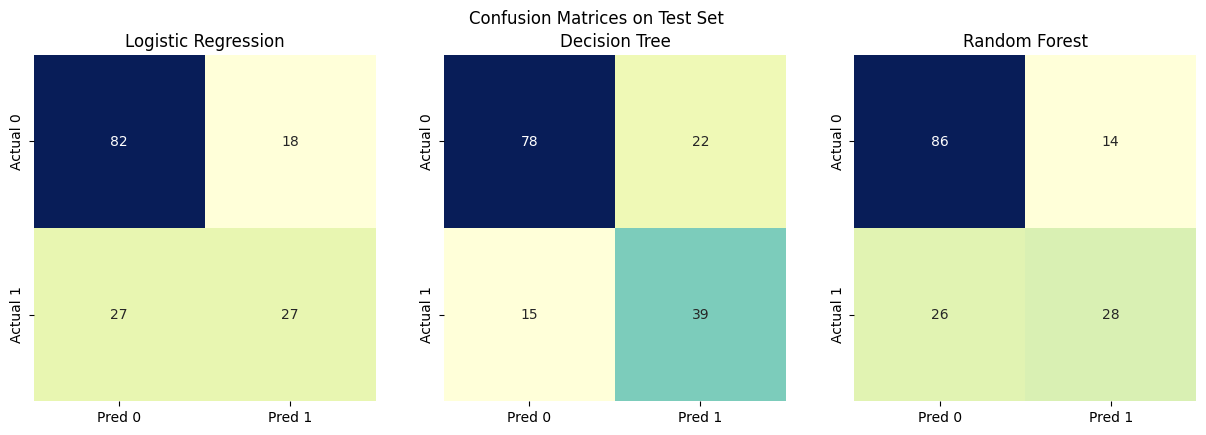

In [24]:
#visualizing all 3 confusion matrices side by side
fig,axes=plt.subplots(1,3,figsize=(15,4.5))
for ax,(name,cm) in zip(axes,[('Logistic Regression',cm_log),('Decision Tree',cm_tree),('Random Forest',cm_rf)]):
    sns.heatmap(cm,annot=True,fmt='d',cmap='YlGnBu',cbar=False,ax=ax,
                xticklabels=['Pred 0','Pred 1'],yticklabels=['Actual 0','Actual 1'])
    ax.set_title(name)
plt.suptitle('Confusion Matrices on Test Set')
plt.show()

In [25]:
#Decision Tree confusion matrix breakdown (best performing model)
tn,fp,fn,tp=cm_tree.ravel()
print('True Negatives (correctly predicted No Diabetes):',tn)
print('False Positives (incorrectly predicted Diabetes):',fp)
print('False Negatives (incorrectly predicted No Diabetes, but patient has diabetes):',fn)
print('True Positives (correctly predicted Diabetes):',tp)
#False Negatives are the most costly error type in a medical screening context - missing an actual diabetes case

True Negatives (correctly predicted No Diabetes): 78
False Positives (incorrectly predicted Diabetes): 22
False Negatives (incorrectly predicted No Diabetes, but patient has diabetes): 15
True Positives (correctly predicted Diabetes): 39


In [26]:
#comparing all 3 models on Accuracy, Precision, Recall and F1 (test set)
comparison=pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Train Accuracy':[accuracy_score(y_train,log_reg_train_pred),accuracy_score(y_train,dec_tree_train_pred),accuracy_score(y_train,rand_forest_train_pred)],
    'Test Accuracy':[accuracy_score(y_test,log_reg_test_pred),accuracy_score(y_test,dec_tree_test_pred),accuracy_score(y_test,rand_forest_test_pred)],
    'Precision':[precision_score(y_test,log_reg_test_pred),precision_score(y_test,dec_tree_test_pred),precision_score(y_test,rand_forest_test_pred)],
    'Recall':[recall_score(y_test,log_reg_test_pred),recall_score(y_test,dec_tree_test_pred),recall_score(y_test,rand_forest_test_pred)],
    'F1-Score':[f1_score(y_test,log_reg_test_pred),f1_score(y_test,dec_tree_test_pred),f1_score(y_test,rand_forest_test_pred)],
})
comparison
#Decision Tree has the best Recall and F1-Score on the test set among the 3 models

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.796417,0.707792,0.600000,0.500000,0.545455
1,Decision Tree,0.814332,0.759740,0.639344,0.722222,0.678261
2,Random Forest,0.884365,0.740260,0.666667,0.518519,0.583333


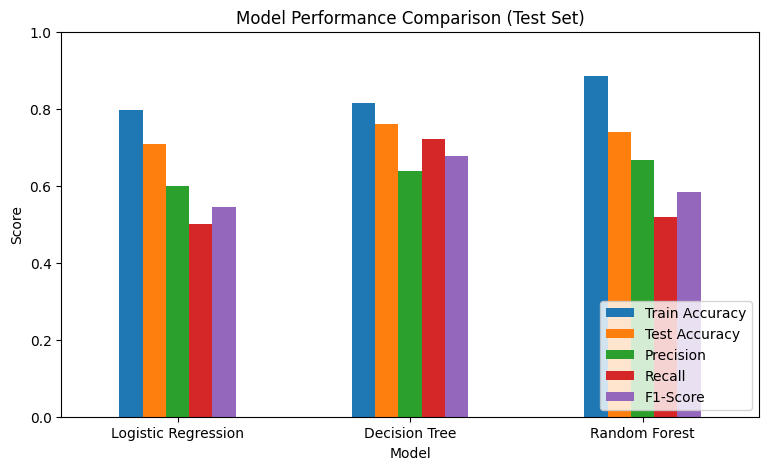

In [27]:
comparison.set_index('Model')[['Train Accuracy','Test Accuracy','Precision','Recall','F1-Score']].plot(kind='bar',figsize=(9,5))
plt.title('Model Performance Comparison (Test Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

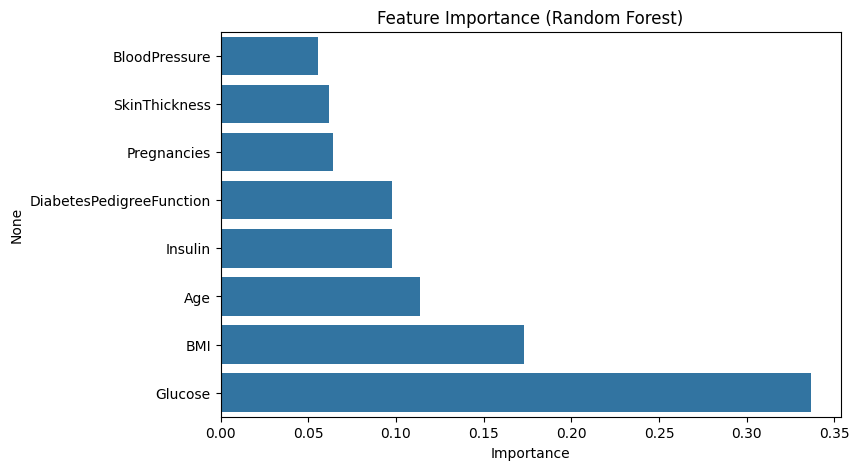

In [28]:
#feature importance from Random Forest - which features matter most for prediction
importance=pd.Series(rand_forest.feature_importances_,index=X.columns).sort_values()
plt.figure(figsize=(8,5))
sns.barplot(x=importance.values,y=importance.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()
#Glucose is by far the most important predictor, followed by BMI and Age

Part 5 - Model Performance Analysis

**1. Most important metric:** For diabetes prediction, **Recall** (sensitivity) is the most important metric. A False Negative here means telling a diabetic patient they are healthy, which delays treatment and is medically dangerous. Missing a positive case (low recall) is worse than a False Positive (which just leads to an extra confirmatory test). So we prioritize a model with high Recall without sacrificing too much Precision (balanced by F1-Score).

**2. Is the model performing well?** The Decision Tree is the best-performing model here (Accuracy ~76%, Recall ~72%, F1 ~0.68). This is a reasonable but not excellent result for a real medical screening tool - about 1 in 4 diabetic patients in the test set would still be missed (False Negatives). Random Forest, despite the highest training accuracy, generalizes slightly worse on this run and has lower Recall than the Decision Tree. Logistic Regression is the most consistent (smallest train-test gap) but has the lowest Recall of the three.

**3. Limitations:**
- The dataset is relatively small (768 records) and moderately imbalanced (65% / 35%), which limits how well the model learns the minority (diabetic) class.
- Several features had a large proportion of hidden missing values (Insulin: 374/768, SkinThickness: 227/768) that had to be imputed with the median, which introduces some noise/bias.
- The dataset only contains a fixed set of medical attributes for female Pima Indian patients, so the model may not generalize well to other populations.

**4. Recommendations to improve performance:**
- **Handle class imbalance** using techniques like SMOTE (synthetic oversampling) or class-weighting (`class_weight='balanced'`) so the model pays more attention to the minority diabetic class and improves Recall.
- **Hyperparameter tuning** (e.g. GridSearchCV/RandomizedSearchCV over `max_depth`, `n_estimators`, `min_samples_leaf`) to find a better bias-variance tradeoff, especially for the Random Forest which currently overfits slightly.
- Additional ideas: feature engineering (e.g. BMI categories, Glucose bins), feature selection to remove low-importance features (BloodPressure, SkinThickness), and trying other algorithms such as Gradient Boosting / XGBoost.